
# Scientific programming video game prediction

## Libraries used

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.iforest import IForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from pyod.models.knn import KNN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


# Loading the dataset + descriptive stats


Number of duplicate game IDs: 0
blueHeralds                     3
blueWardsDestroyed              2
blueCSPerMin                    2
redDeaths                       2
redFirstBlood                   1
blueWardsPlaced                 1
blueDeaths                      1
blueAssists                     1
redTotalExperience              1
redExperienceDiff               1
redKills                        1
redWardsDestroyed               1
redWardsPlaced                  1
redTotalJungleMinionsKilled     1
blueWins                        0
gameId                          0
blueFirstBlood                  0
blueKills                       0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueEliteMonsters               0
blueDragons                     0
blueTowersDestroyed             0
blueGoldPerMin                  0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueTotalGold   

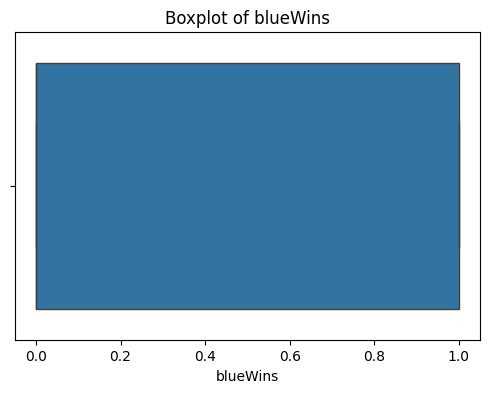

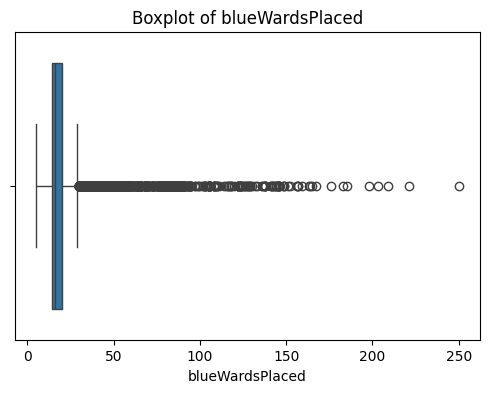

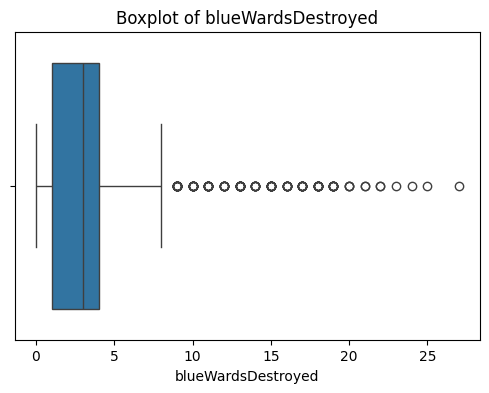

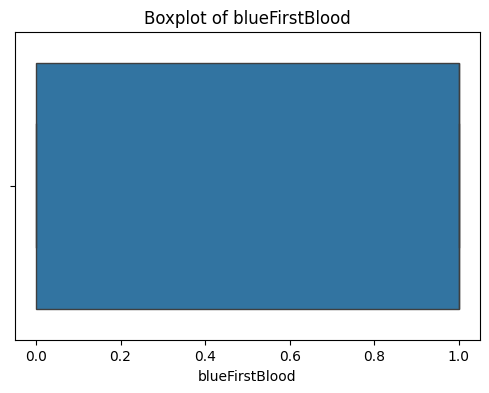

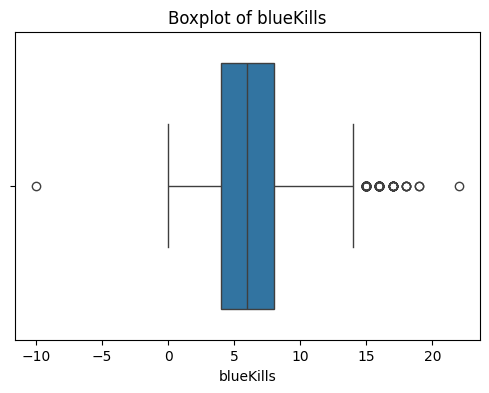

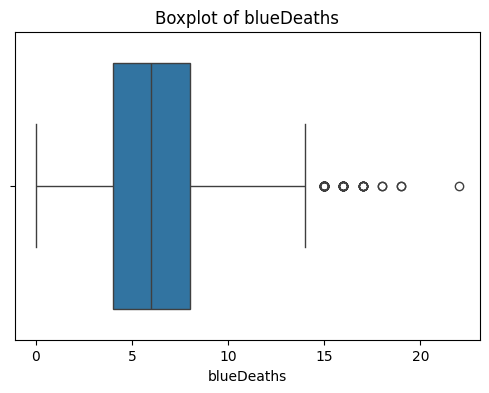

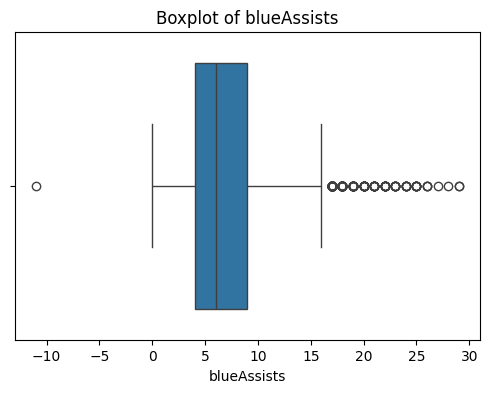

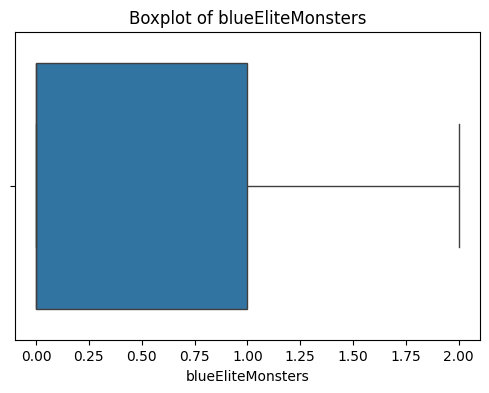

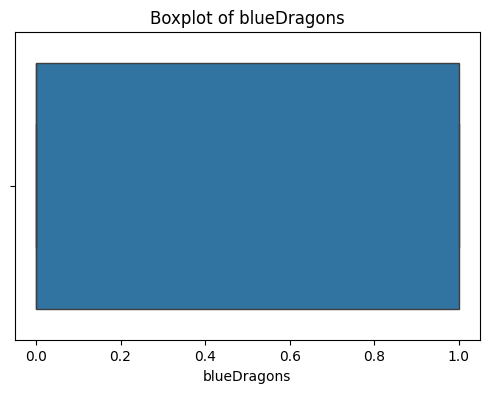

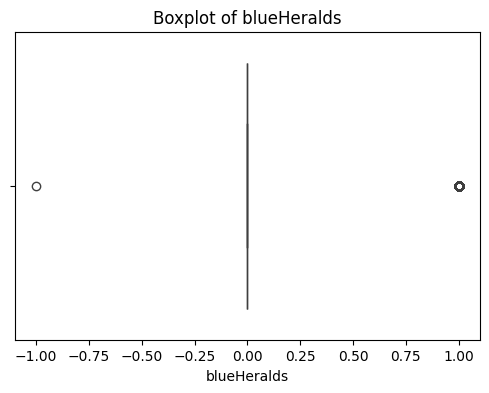

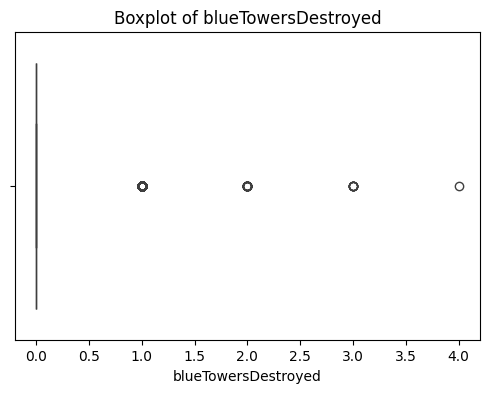

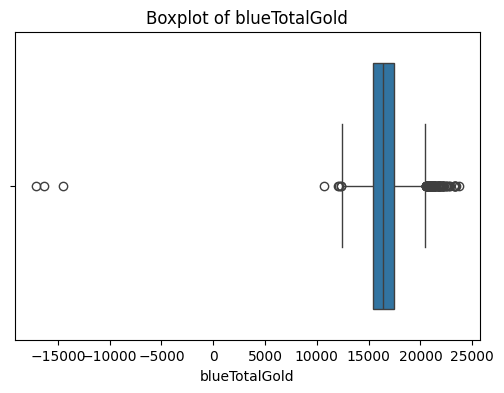

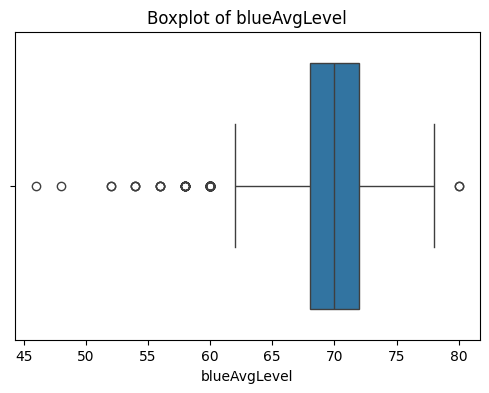

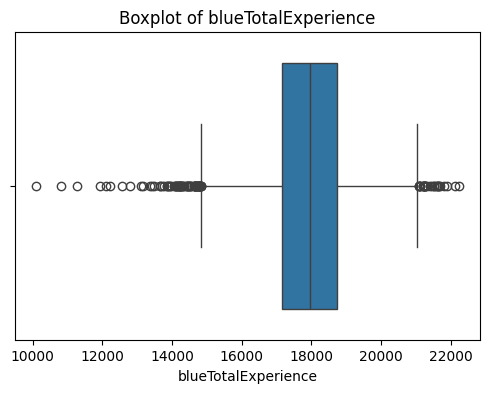

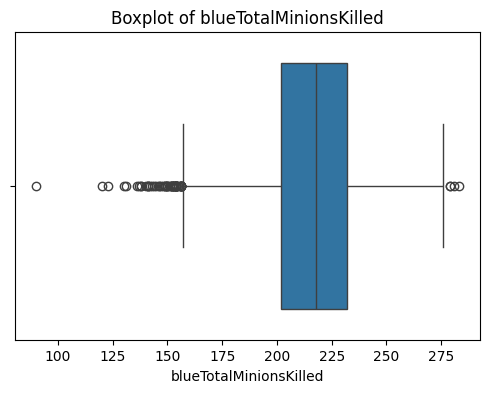

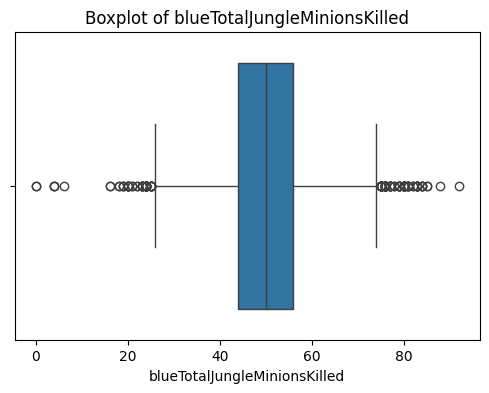

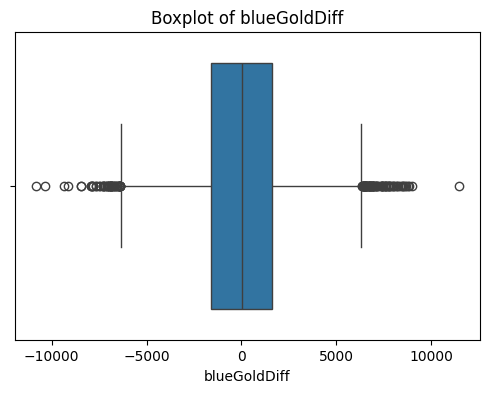

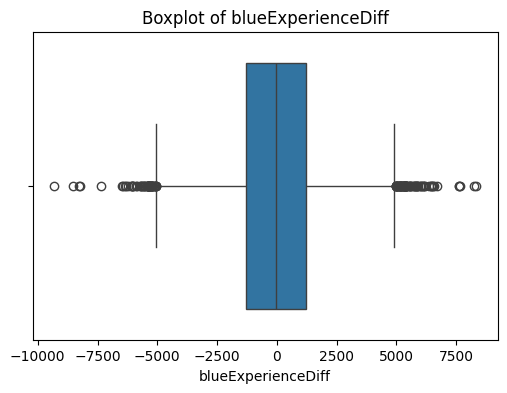

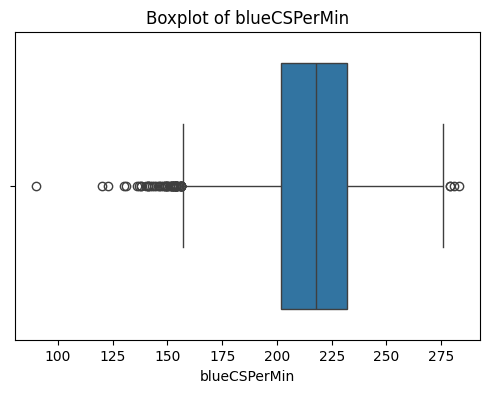

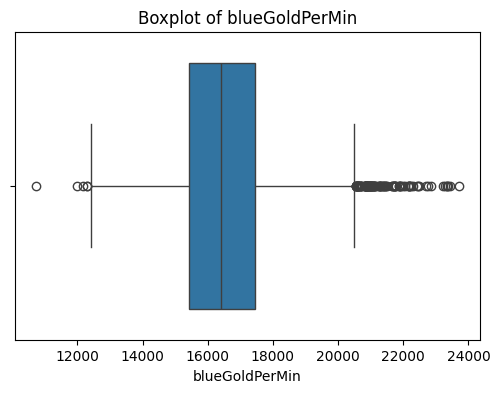

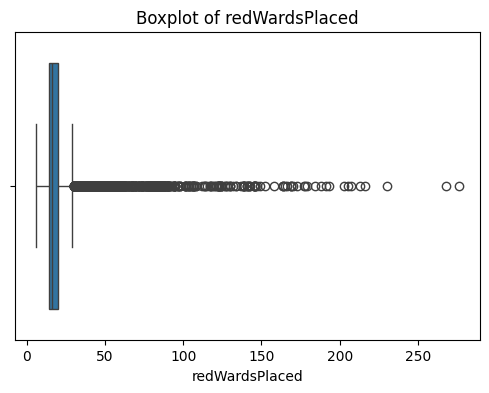

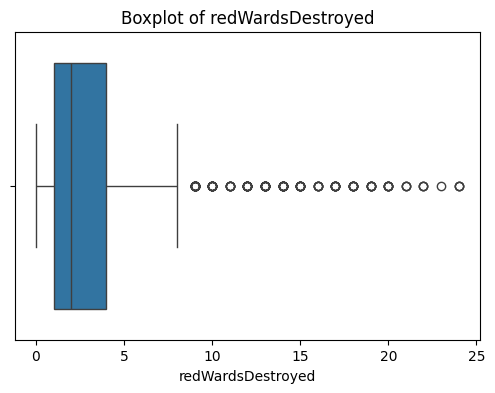

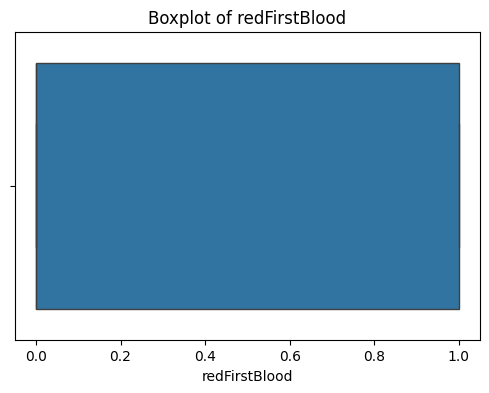

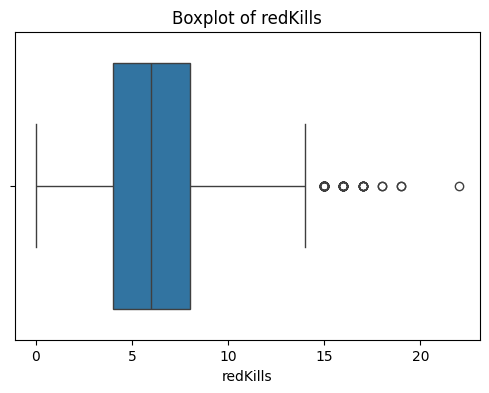

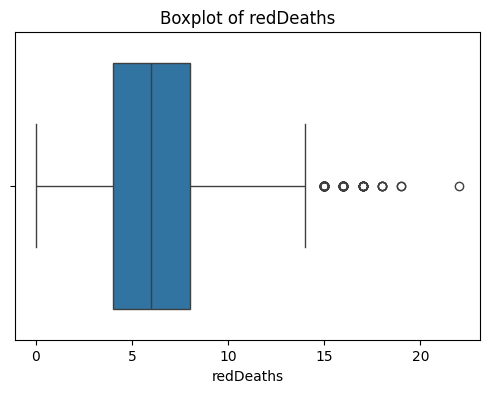

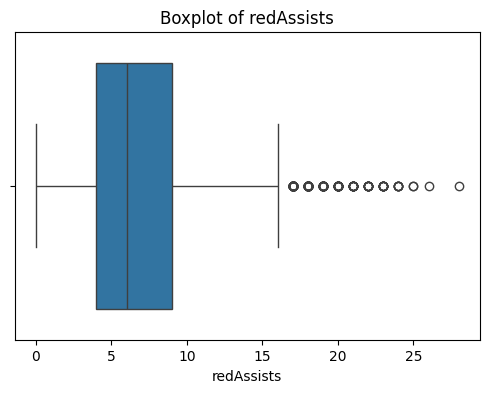

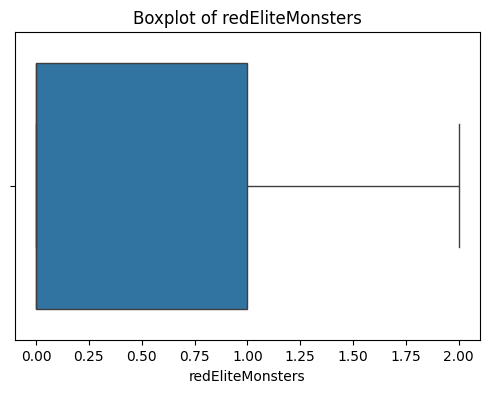

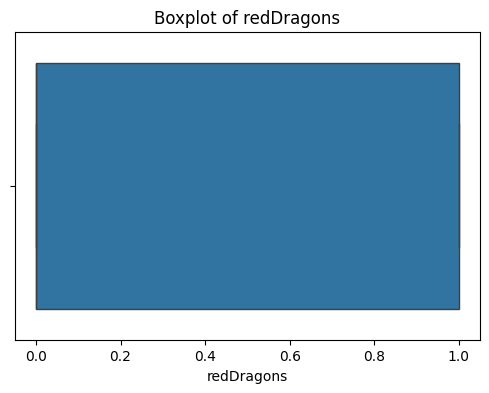

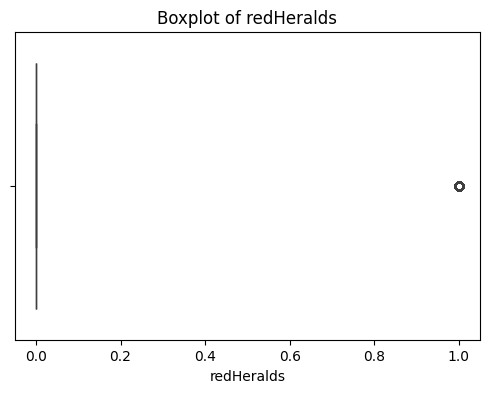

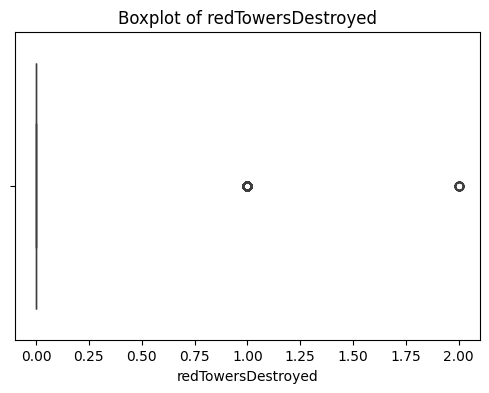

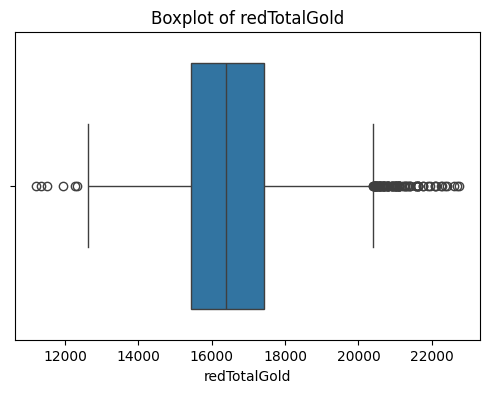

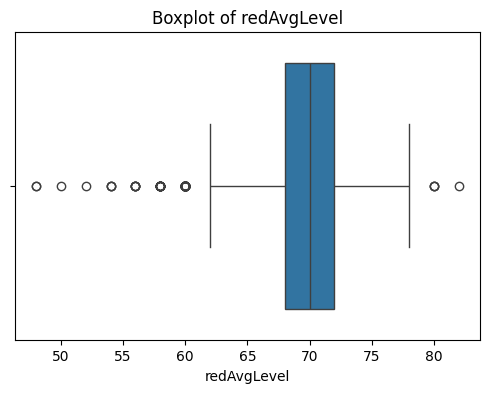

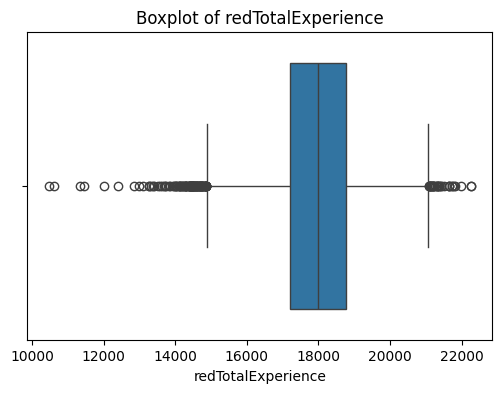

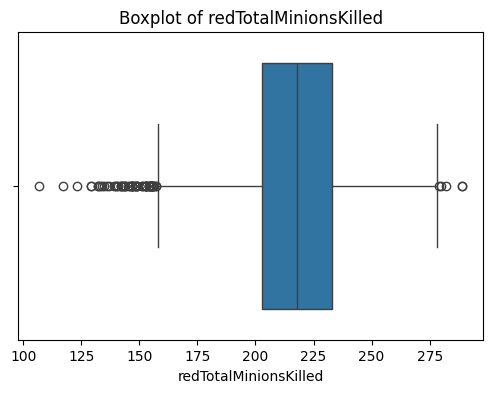

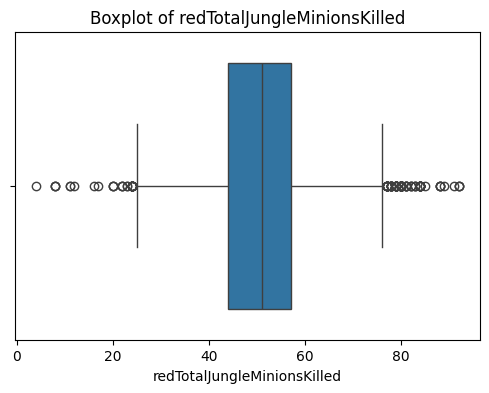

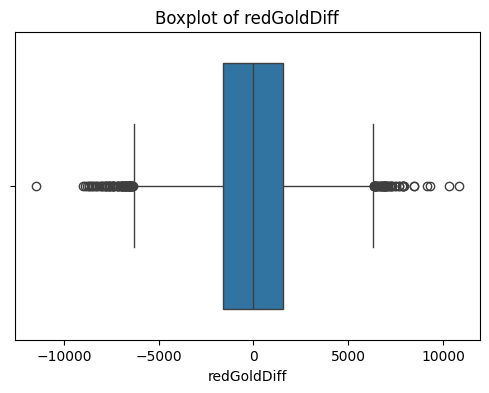

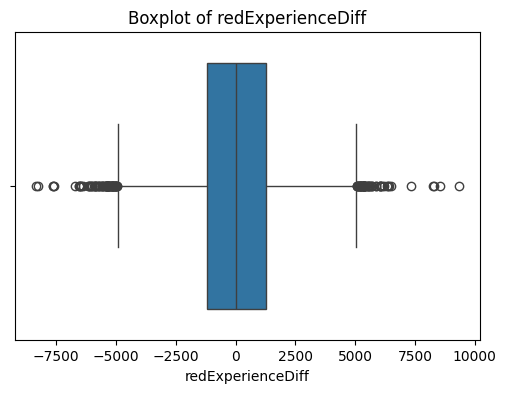

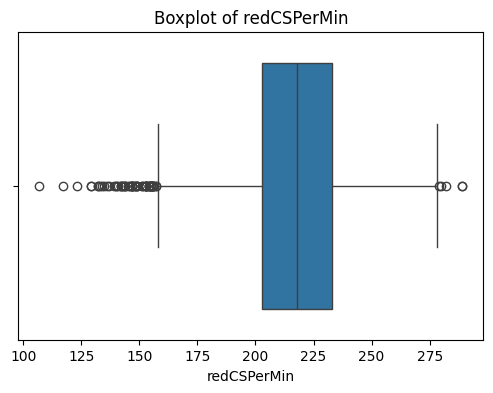

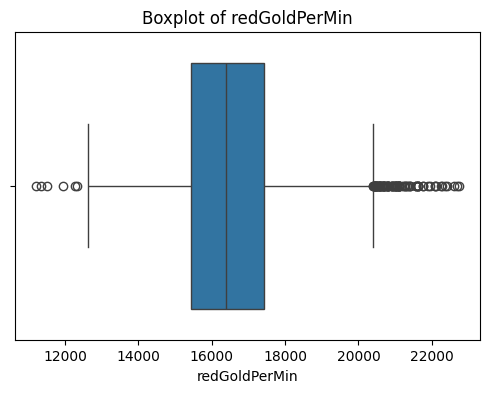

In [ ]:
#Load the videogame data excell file
data = pd.read_csv("Videogamedata_dirty.csv", sep = ";")

#Clean data version
cleandata = pd.read_csv("Videogamedata.csv")

#Check for any dupliate gameId values
num_dupes = data['gameId'].duplicated().sum()
print("Number of duplicate game IDs:", num_dupes)

#Check for missing values
print(data.isnull().sum().sort_values(ascending=False))

#Visualize distributions of numeric columns using boxplots
numeric_cols = [col for col in data.select_dtypes(include=['number']).columns 
                if col != 'gameId']  # exclude gameID

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Select numeric data
X = data[numeric_cols]

# Build an IterativeImputer using random forests
imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                       max_iter=10, random_state=42)

X_imputed = imp.fit_transform(X)  # numpy array with NaNs filled

# Make a new DataFrame with imputed values
imputed_df_IF = pd.DataFrame(X_imputed, columns=numeric_cols, index=data.index)

# Now run Isolation Forest
clf = IForest(contamination=0.05, n_estimators=200, random_state=42)
clf.fit(X_imputed)

labels = clf.labels_
scores = clf.decision_scores_

imputed_df_IF['outlier_flag'] = labels
imputed_df_IF['outlier_score'] = scores

print("Number of outliers:", (labels == 1).sum())

# Keep only inliers (label == 0)
cleaned_imputed_df_IF = imputed_df_IF[imputed_df_IF['outlier_flag'] == 0].copy()

print("Remaining rows after removing outliers:", cleaned_imputed_df_IF.shape[0])

# --- Run KNN on the same imputed data ---
knn = KNN(n_neighbors=5, contamination=0.05, method='largest')  
# method can be 'largest', 'mean', or 'median' (how to aggregate neighbor distances)
knn.fit(X_imputed)

knn_labels = knn.labels_
knn_scores = knn.decision_scores_

imputed_df_KNN = pd.DataFrame(X_imputed, columns=numeric_cols, index=data.index)

# Add KNN results to the imputed_df as new columns
imputed_df_KNN['knn_outlier_flag'] = knn_labels
imputed_df_KNN['knn_outlier_score'] = knn_scores

print("KNN - number of outliers:", (knn_labels == 1).sum())

# Compare overlap between IF and KNN
overlap = ((labels == 1) & (knn_labels == 1)).sum()
print("Overlap of IF + KNN outliers:", overlap)

agreement = np.mean(labels == knn_labels)
print(f"Agreement between IF and KNN: {agreement:.2%}")

# Keep only inliers (label == 0)
cleaned_imputed_df_knn = imputed_df_KNN[imputed_df_KNN['knn_outlier_flag'] == 0].copy()




Accuracy: 0.7176113360323887
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       990
           1       0.72      0.71      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



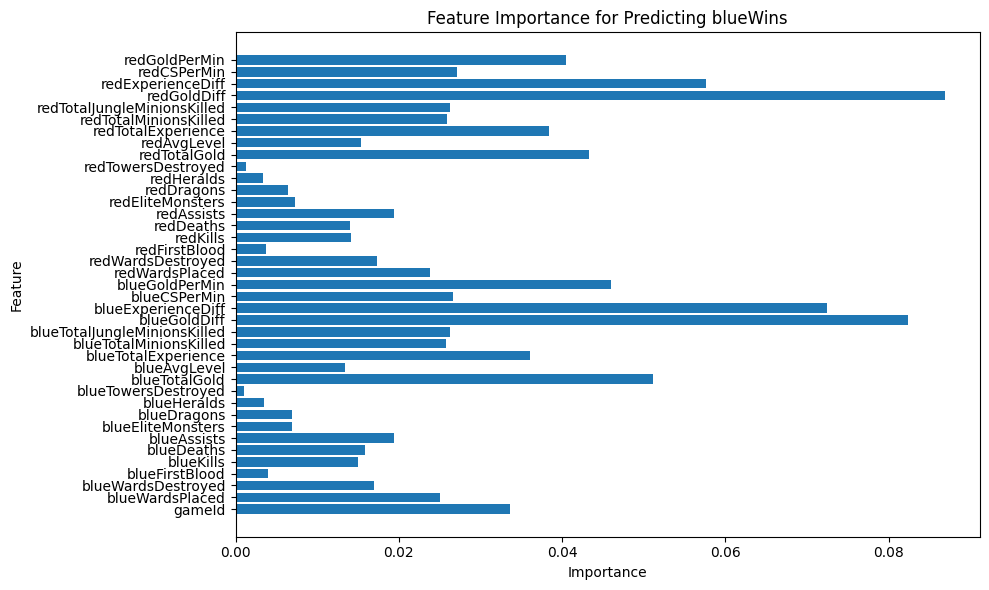

In [ ]:
#Split into features and target
X = data.drop(columns=['blueWins'])        # explanatory variables
y = data['blueWins']                       # target variable

#Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # reproducible split
    stratify=y             # keep class balance
)

#Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

#Predictions
y_pred = rf_model.predict(X_test)

#Accuracy & report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Feature importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns  # use your X’s column names

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting blueWins")
plt.tight_layout()
plt.show()

# Isolation forest ML

Model performance on test set:

Logistic Regression  accuracy: 0.716
SVM (RBF kernel)     accuracy: 0.716
k-NN                 accuracy: 0.691
Naive Bayes          accuracy: 0.717
Decision Tree        accuracy: 0.643
Random Forest        accuracy: 0.717
Gradient Boosting    accuracy: 0.720


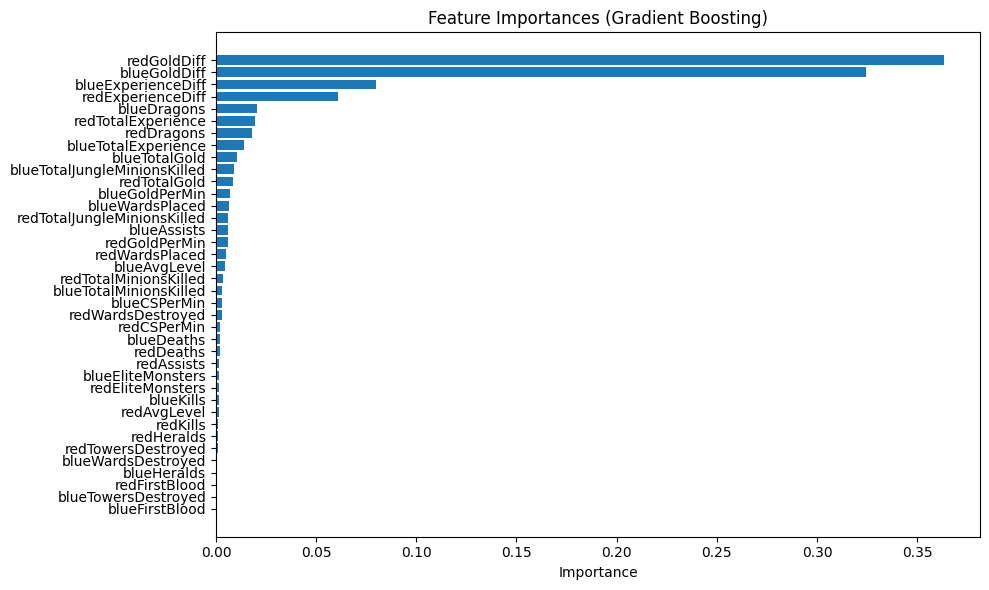

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_IF.drop(columns=['blueWins', 'gameId','outlier_flag','outlier_score'], errors='ignore')
y = cleaned_imputed_df_IF['blueWins']

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features for models that need it
# (SVM, k-NN, LogisticRegression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF kernel)": SVC(),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Evaluate each model
print("Model performance on test set:\n")
for name, model in models.items():
    # use scaled data for models that benefit from it
    if name in ["Logistic Regression", "SVM (RBF kernel)", "k-NN"]:
        model.fit(X_train_scaled, y_train)
        score = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
    print(f"{name:20s} accuracy: {score:.3f}")

# Dive a little deeper into gradient boosting
# Get the trained Gradient Boosting model from your dict
gb_model = models["Gradient Boosting"]

# Get feature importances
gb_importances = gb_model.feature_importances_
gb_sorted_idx = np.argsort(gb_importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(gb_sorted_idx)), gb_importances[gb_sorted_idx], align='center')
plt.yticks(range(len(gb_sorted_idx)), [X.columns[i] for i in gb_sorted_idx])
plt.xlabel("Importance")
plt.title("Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()

# kNN ML

In [ ]:
# Drop unnecessary columns
X = cleaned_imputed_df_knn.drop(columns=['blueWins', 'gameId','knn_outlier_flag','knn_outlier_score'], errors='ignore')
y = cleaned_imputed_df_knn['blueWins']

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features for models that need it
# (SVM, k-NN, LogisticRegression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF kernel)": SVC(),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Evaluate each model
print("Model performance on test set:\n")
for name, model in models.items():
    # use scaled data for models that benefit from it
    if name in ["Logistic Regression", "SVM (RBF kernel)", "k-NN"]:
        model.fit(X_train_scaled, y_train)
        score = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
    print(f"{name:20s} accuracy: {score:.3f}")

# Dive a little deeper into gradient boosting
# Get the trained Gradient Boosting model from your dict
gb_model = models["Gradient Boosting"]

# Get feature importances
gb_importances = gb_model.feature_importances_
gb_sorted_idx = np.argsort(gb_importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(gb_sorted_idx)), gb_importances[gb_sorted_idx], align='center')
plt.yticks(range(len(gb_sorted_idx)), [X.columns[i] for i in gb_sorted_idx])
plt.xlabel("Importance")
plt.title("Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()

# Neural netork (not yet comparing both data cleaning techniques)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

##Testing neural network
# Define a neural network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers with 64 and 32 neurons
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train
mlp.fit(X_train_scaled, y_train)

# Evaluate
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6629554655870445
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       990
           1       0.66      0.67      0.67       986

    accuracy                           0.66      1976
   macro avg       0.66      0.66      0.66      1976
weighted avg       0.66      0.66      0.66      1976



c:\Users\semmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
